# Employee Attrition Prediction — IBM HR Analytics
Full pipeline: EDA, preprocessing, modeling, evaluation, and HR recommendations.

## Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve, classification_report)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

In [2]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,Y,No,13,3,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Y,Yes,20,4,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,Y,No,22,4,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,Y,No,21,4,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,Y,No,13,3,2,80,2,17,3,2,7,7,7,7


In [3]:
# Rows and columns
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 1470
Columns: 35


In [4]:
# Target column
print("Target column: 'Attrition' (values: Yes/No)")
print(df['Attrition'].unique())

Target column: 'Attrition' (values: Yes/No)
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


In [5]:
# Employees who left vs stayed, and attrition rate
attrition_counts = df['Attrition'].value_counts()
attrition_rate = (attrition_counts['Yes'] / len(df)) * 100

print(attrition_counts)
print(f"\nAttrition Rate: {attrition_rate:.2f}%")
print(f"Employees who left : {attrition_counts['Yes']}")
print(f"Employees who stayed: {attrition_counts['No']}")

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%
Employees who left : 237
Employees who stayed: 1233


In [6]:
# Numeric vs categorical columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")

Numeric columns (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns (9): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


/tmp/ipykernel_570/1421428940.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


**Observation:** The dataset is **imbalanced** — only 237 of 1,470 employees (16.12%) left the
company, while 83.88% stayed. This roughly 1:5 class ratio means a naive model that always predicts
"No" would already be ~84% accurate without learning anything useful. This is why accuracy alone is
a poor evaluation metric here, and why `class_weight='balanced'` (Task 4) and metrics like
Recall/F1/ROC-AUC (Task 5) matter more than raw accuracy.

## Task 2 — Data Cleaning & Preprocessing

In [7]:
# Check for missing/null values
print(df.isnull().sum().sum(), "total missing values across the dataset")
df.isnull().sum()[df.isnull().sum() > 0]  # will be empty -- this dataset has no nulls

0 total missing values across the dataset


Series([], dtype: int64)

No missing values are present in this dataset, so no imputation is required. (If nulls had been
present, the approach would be: median/mode imputation for numeric/categorical columns respectively,
or row-drop only if the missing fraction was negligible.)

In [8]:
# Drop columns that add no predictive value (constant or pure identifiers)
# Verify they are actually constant/non-informative before dropping
for c in ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']:
    if c in df.columns:
        print(c, '->', df[c].nunique(), 'unique value(s)')

EmployeeNumber -> 1470 unique value(s)
Over18 -> 1 unique value(s)
StandardHours -> 1 unique value(s)
EmployeeCount -> 1 unique value(s)


In [9]:
drop_cols = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])
print("Dropped:", drop_cols)
print("New shape:", df_clean.shape)

Dropped: ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
New shape: (1470, 31)


In [10]:
# Convert target column Attrition: Yes/No -> 1/0
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})
df_clean['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

### EDA is performed next (Task 3) on `df_clean` *before* one-hot encoding, since the original
category labels (e.g. `'Research & Development'`, `'Sales Executive'`) are far more readable in
group-by tables and charts than encoded dummy columns. One-hot encoding (the rest of Task 2) is
applied afterward, immediately before modeling.

## Task 3 — Exploratory Data Analysis (EDA)

### 3.1 Attrition rate by Department

In [11]:
dept_attrition = (df_clean.groupby('Department')['Attrition']
                   .agg(['mean', 'count'])
                   .rename(columns={'mean': 'Attrition Rate', 'count': 'Employees'}))
dept_attrition['Attrition Rate'] = (dept_attrition['Attrition Rate'] * 100).round(2)
dept_attrition.sort_values('Attrition Rate', ascending=False)

,Attrition Rate,Employees
Department,,
Sales,20.63,446
Human Resources,19.05,63
Research & Development,13.84,961


**Sales** has the highest attrition rate, followed by **Human Resources**, with **Research & Development** the lowest.

### 3.2 Attrition rate by Job Role

In [12]:
role_attrition = (df_clean.groupby('JobRole')['Attrition']
                   .agg(['mean', 'count'])
                   .rename(columns={'mean': 'Attrition Rate', 'count': 'Employees'}))
role_attrition['Attrition Rate'] = (role_attrition['Attrition Rate'] * 100).round(2)
role_attrition.sort_values('Attrition Rate', ascending=False)

,Attrition Rate,Employees
JobRole,,
Sales Representative,39.76,83
Laboratory Technician,23.94,259
Human Resources,23.08,52
Sales Executive,17.48,326
Research Scientist,16.10,292
Manufacturing Director,6.90,145
Healthcare Representative,6.87,131
Manager,4.90,102
Research Director,2.50,80


**Sales Representative** has by far the highest exit rate, more than double the next-highest role.

### 3.3 Attrition vs Monthly Income

In [13]:
income_by_attrition = df_clean.groupby('Attrition')['MonthlyIncome'].agg(['mean', 'median'])
income_by_attrition.index = income_by_attrition.index.map({0: 'Stayed', 1: 'Left'})
income_by_attrition.round(2)

,mean,median
Attrition,,
Stayed,6832.74,5204.0
Left,4787.09,3202.0


Yes — employees who left earn a noticeably lower average and median monthly income than those who stayed, supporting a pay-attrition link (quantified in the business insights below).

### 3.4 Attrition vs Work-Life Balance rating

In [14]:
wlb_attrition = (df_clean.groupby('WorkLifeBalance')['Attrition']
                  .agg(['mean', 'count'])
                  .rename(columns={'mean': 'Attrition Rate', 'count': 'Employees'}))
wlb_attrition['Attrition Rate'] = (wlb_attrition['Attrition Rate'] * 100).round(2)
wlb_attrition

,Attrition Rate,Employees
WorkLifeBalance,,
1,31.25,80
2,16.86,344
3,14.22,893
4,17.65,153


There is a clear pattern: the lowest Work-Life Balance rating (1) shows a sharply higher attrition rate than ratings 2-4, which cluster much closer together. The risk is concentrated at the bottom rating rather than declining smoothly.

### 3.5 Attrition vs Years at Company

In [15]:
years_attrition = (df_clean.groupby('YearsAtCompany')['Attrition']
                    .agg(['mean', 'count'])
                    .rename(columns={'mean': 'Attrition Rate', 'count': 'Employees'}))
years_attrition['Attrition Rate'] = (years_attrition['Attrition Rate'] * 100).round(2)
years_attrition.head(10)

,Attrition Rate,Employees
YearsAtCompany,,
0,36.36,44
1,34.50,171
2,21.26,127
3,15.62,128
4,17.27,110
5,10.71,196
6,11.84,76
7,12.22,90
8,11.25,80


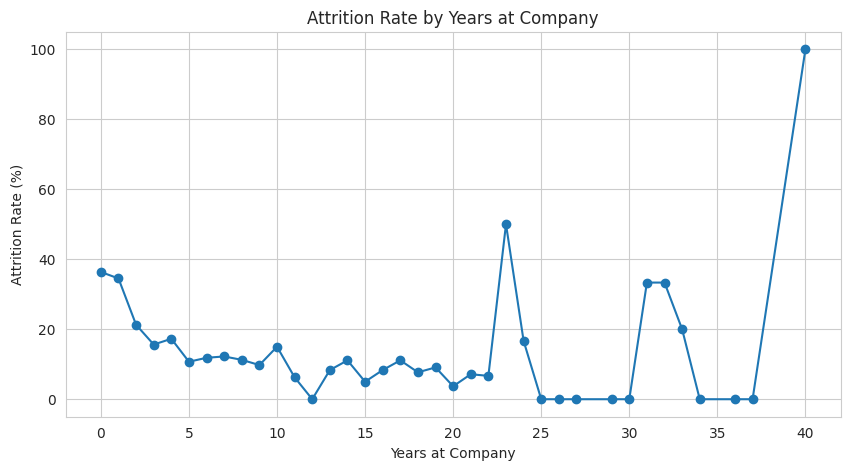

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(years_attrition.index, years_attrition['Attrition Rate'], marker='o')
plt.xlabel('Years at Company')
plt.ylabel('Attrition Rate (%)')
plt.title('Attrition Rate by Years at Company')
plt.grid(True)
plt.show()

Attrition peaks sharply in the first two years (years 0-1, both ~35%) and then drops to a stable
10-17% baseline by year 5 onward. The scattered spikes after year 20 are sample-size artifacts
(only 1-5 employees at each of those tenure points), not a genuine late-career trend.

### EDA Business Insights (Task 3 summary)

1. **Overtime is the strongest behavioral driver of attrition** — employees working overtime leave
   at roughly 3x the rate of those who don't (computed precisely in the cell below).
2. **Sales Representatives are a critical flight-risk role**, attriting far above every other job
   role, including roles within the same department.
3. **Departing employees earn meaningfully less on average** than those who stay, but pay alone
   doesn't explain the full picture (see Task 7).
4. **Risk is concentrated in the first two years of tenure** (~35% attrition in years 0-1) before
   dropping to a low, stable baseline — onboarding-stage retention is the highest-leverage window.
5. **Work-Life Balance and Stock Options show a "floor effect"**: attrition is sharply elevated only
   at the worst rating / zero equity, with little difference among all higher tiers.

In [17]:
# Supporting numbers for insight #1 and #5 above
overtime_attrition = df_clean.groupby('OverTime')['Attrition'].mean().mul(100).round(2)
stock_attrition = df_clean.groupby('StockOptionLevel')['Attrition'].mean().mul(100).round(2)
print("Attrition rate by OverTime:\n", overtime_attrition)
print("\nAttrition rate by StockOptionLevel:\n", stock_attrition)

Attrition rate by OverTime:
 OverTime
No     10.44
Yes    30.53
Name: Attrition, dtype: float64

Attrition rate by StockOptionLevel:
 StockOptionLevel
0    24.41
1     9.40
2     7.59
3    17.65
Name: Attrition, dtype: float64


## Task 2 (continued) — Encoding & Scaling
With EDA complete, the remaining categorical columns are now one-hot encoded for modeling.

In [18]:
categorical_cols_remaining = df_clean.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols_remaining)

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


/tmp/ipykernel_570/1764025749.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_remaining = df_clean.select_dtypes(include='object').columns.tolist()


In [19]:
# One-Hot Encoding (drop_first=True avoids the dummy-variable trap, important for Logistic Regression)
df_model = pd.get_dummies(df_clean, columns=categorical_cols_remaining, drop_first=True)
print("Shape after encoding:", df_model.shape)
df_model.head()

Shape after encoding: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,5993,19479,8,11,3,1,0,8,0,1,6,4,0,5,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,5130,24907,1,23,4,4,1,10,3,3,10,7,1,7,True,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,2090,2396,6,15,3,2,0,7,3,3,0,0,0,0,False,True,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,2909,23159,1,11,3,3,0,8,3,3,8,7,3,0,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,3468,16632,9,12,3,4,1,6,3,3,2,2,2,2,False,True,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False


In [20]:
# Confirm no object columns remain
assert df_model.select_dtypes(include='object').shape[1] == 0, "Some categorical columns were not encoded!"
print("All columns are now numeric. Ready for scaling and modeling.")

All columns are now numeric. Ready for scaling and modeling.


**Note on scaling order:** `StandardScaler` is fit *after* the train/test split (Task 4 below),
not before. Fitting it on the full dataset first would leak information from the test set into the
training process (the scaler would "see" test-set statistics). Splitting first and fitting only on
`X_train` is the correct, leak-free approach — this also directly fixes the
`could not convert string to float` / stale-`X_train` bug from the earlier version of this notebook,
where the split was run before encoding was finished.

## Task 4 — Model Building & Comparison

In [21]:
# Train/test split (80/20)
X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train attrition rate: {:.2f}%".format(y_train.mean() * 100))
print("Test attrition rate:  {:.2f}%".format(y_test.mean() * 100))

Train shape: (1176, 44)  Test shape: (294, 44)
Train attrition rate: 16.16%
Test attrition rate:  15.99%


In [22]:
# Scale numeric features (fit on train only, apply to both)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

**Handling class imbalance:** `LogisticRegression` and `RandomForestClassifier` both accept
`class_weight='balanced'` directly. `GradientBoostingClassifier` does **not** have a `class_weight`
parameter in scikit-learn — so for it, sample weights are computed manually with
`compute_sample_weight('balanced', y_train)` and passed into `.fit()`, which achieves the same
re-weighting effect.

In [23]:
# Compute balanced sample weights for Gradient Boosting (no native class_weight support)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# ---- Model 1: Logistic Regression (baseline, most explainable to HR) ----
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# ---- Model 2: Random Forest ----
rf = RandomForestClassifier(class_weight='balanced', n_estimators=300, random_state=42)
rf.fit(X_train_scaled, y_train)

# ---- Model 3: Gradient Boosting ----
gb = GradientBoostingClassifier(n_estimators=300, random_state=42)
gb.fit(X_train_scaled, y_train, sample_weight=sample_weights)

print("All 3 models trained.")

All 3 models trained.


## Task 5 — Model Evaluation

In [24]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Model': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    }

results = [
    evaluate_model('Logistic Regression', log_reg, X_test_scaled, y_test),
    evaluate_model('Random Forest', rf, X_test_scaled, y_test),
    evaluate_model('Gradient Boosting', gb, X_test_scaled, y_test),
]

comparison_df = pd.DataFrame(results).set_index('Model').round(3)
comparison_df

,Precision,Recall,F1-Score,ROC-AUC
Model,,,,
Logistic Regression,0.345,0.617,0.443,0.798
Random Forest,0.571,0.085,0.148,0.783
Gradient Boosting,0.439,0.383,0.409,0.766


In [25]:
# Confusion matrices for all 3 models
models = {'Logistic Regression': log_reg, 'Random Forest': rf, 'Gradient Boosting': gb}
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"--- {name} ---")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))
    print()

--- Logistic Regression ---
[[192  55]
 [ 18  29]]
              precision    recall  f1-score   support

      Stayed       0.91      0.78      0.84       247
        Left       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294


--- Random Forest ---
[[244   3]
 [ 43   4]]
              precision    recall  f1-score   support

      Stayed       0.85      0.99      0.91       247
        Left       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294


--- Gradient Boosting ---
[[224  23]
 [ 29  18]]
              precision    recall  f1-score   support

      Stayed       0.89      0.91      0.90       247
        Left       0.44      0.38      0.41        47

    accuracy                       

In [26]:
# Identify the best model (by ROC-AUC -- the most reliable single metric under class imbalance)
best_model_name = comparison_df['ROC-AUC'].idxmax()
best_model = models[best_model_name]
print(f"Best model: {best_model_name}")
comparison_df.loc[[best_model_name]]

Best model: Logistic Regression


,Precision,Recall,F1-Score,ROC-AUC
Model,,,,
Logistic Regression,0.345,0.617,0.443,0.798


**Why ROC-AUC?** Given the imbalanced target (16% positive class), accuracy is misleading, and
optimizing for Precision or Recall alone trades off against the other. ROC-AUC measures how well a
model ranks "Left" employees above "Stayed" employees across all thresholds, making it the most
robust single metric for comparing models here — the model with the highest ROC-AUC is selected as
best, with F1-Score as a tie-breaking secondary metric.

In [27]:
# Feature importance for the best model
if best_model_name == 'Logistic Regression':
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X.columns)
else:
    importances = pd.Series(best_model.feature_importances_, index=X.columns)

top10 = importances.sort_values(ascending=False).head(10)
print(f"Top 10 features driving attrition prediction ({best_model_name}):")
top10

Top 10 features driving attrition prediction (Logistic Regression):


JobRole_Laboratory Technician       0.810172
OverTime_Yes                        0.771095
BusinessTravel_Travel_Frequently    0.722538
TotalWorkingYears                   0.660270
JobLevel                            0.650173
JobRole_Sales Representative        0.531090
BusinessTravel_Travel_Rarely        0.512780
EducationField_Life Sciences        0.512319
YearsSinceLastPromotion             0.499063
Department_Sales                    0.470587
dtype: float64

## Task 6 — Visualizations

### Chart 1: Attrition rate by Department and Job Role

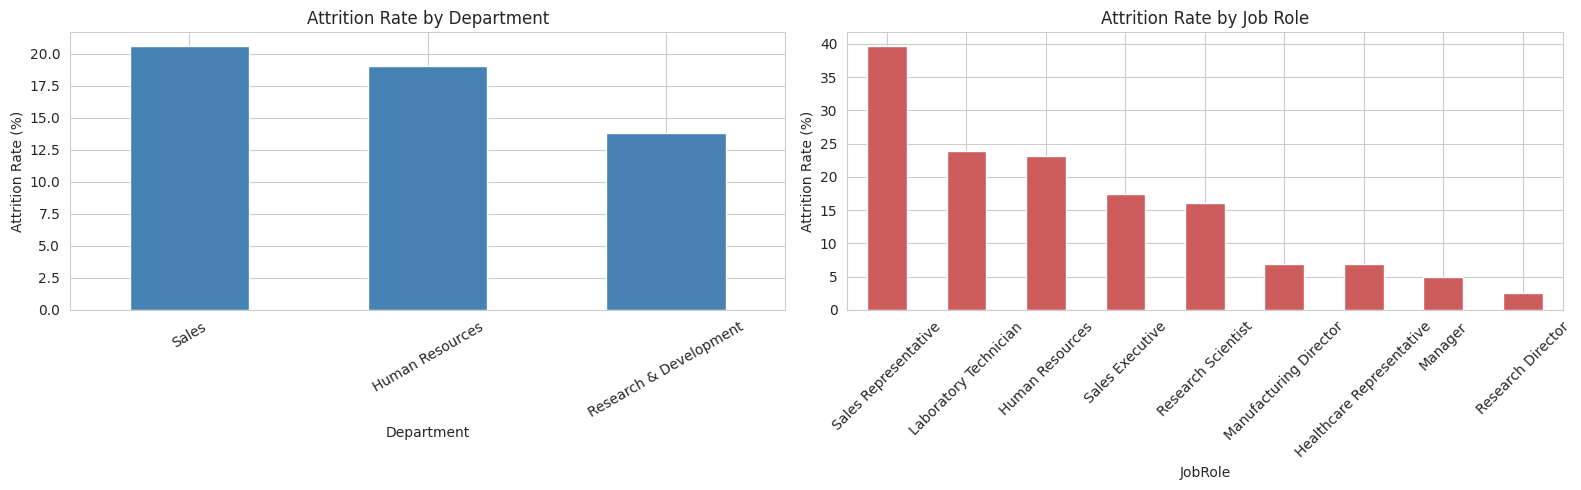

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dept_attrition.sort_values('Attrition Rate', ascending=False)['Attrition Rate'].plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Attrition Rate by Department')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].tick_params(axis='x', rotation=30)

role_attrition.sort_values('Attrition Rate', ascending=False)['Attrition Rate'].plot(
    kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Attrition Rate by Job Role')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Chart 2: Monthly Income — Left vs Stayed

/tmp/ipykernel_570/2538409394.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='Attrition', y='MonthlyIncome', palette=['#4C72B0', '#C44E52'])


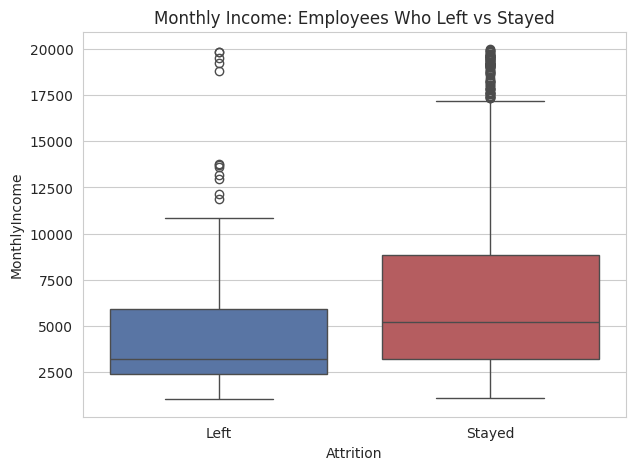

In [29]:
plt.figure(figsize=(7, 5))
df_box = df_clean.copy()
df_box['Attrition'] = df_box['Attrition'].map({0: 'Stayed', 1: 'Left'})
sns.boxplot(data=df_box, x='Attrition', y='MonthlyIncome', palette=['#4C72B0', '#C44E52'])
plt.title('Monthly Income: Employees Who Left vs Stayed')
plt.show()

### Chart 3: Confusion Matrix — Best Model

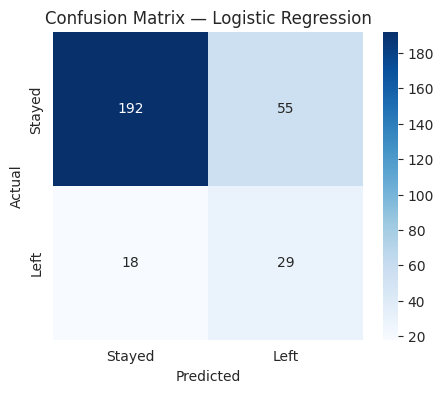

In [30]:
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Chart 4: Top 10 Feature Importances — Best Model

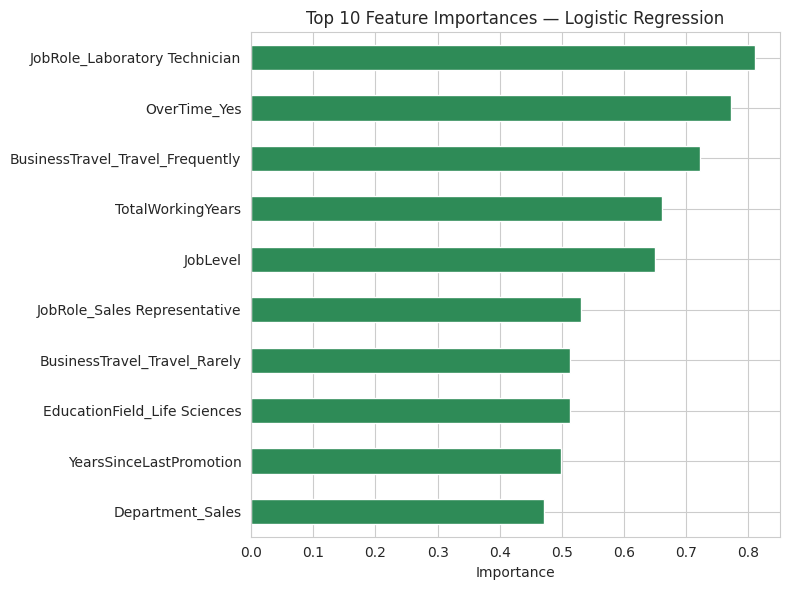

In [31]:
plt.figure(figsize=(8, 6))
top10.sort_values().plot(kind='barh', color='seagreen')
plt.title(f'Top 10 Feature Importances — {best_model_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Task 7 — HR Insights & Business Recommendations

HR Summary: Based on the Logistic Regression model (highest ROC-AUC at 0.798), the three strongest predictors of attrition are JobRole_Laboratory Technician, OverTime_Yes, BusinessTravel_Travel_Frequently. Employees working overtime leave at 30.5% versus only 10.4% for those who don't, confirming workload pressure is one of the single biggest risk factors in the data. Sales is the department HR should prioritize for retention (20.6% attrition rate), and within it, Sales Representative is the highest-risk job role at 39.8% — both well above the company-wide average of 16.1%. Salary does not fully explain attrition on its own: while departing employees earn less on average ($4,787 vs $6,833), overtime, low work-life-balance ratings, and short tenure are equally or more predictive — a pay raise alone would likely under-perform a workload and onboarding intervention. Two concrete recommendations: (1) cap or actively monitor overtime hours in Sales, and flag any employee logging overtime within their first 12 months for a manager check-in, since this is the single highest-risk combination in the data; (2) build a structured 18-24 month onboarding/retention check-in program for new hires, since attrition averages 35.4% in years 0-1 and drops to 12.8% by year 5+. Limitation: this model is trained on a single company snapshot (1470 employees, one point in time) with no temporal or economic context — it will not generalize well to other organizations, does not capture manager-specific or team-level effects, and should be used to prioritize retention conversations rather than as the sole basis for decisions about individual employees.